# ✈ Tải dữ liệu

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/My Drive/colab_python_pkgs')

import optuna

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
path1='/content/drive/MyDrive/Project ML/Dataset/Sale_Forecasting/train - Walmart Sales Forecast.csv'
path2='/content/drive/MyDrive/Project ML/Dataset/Sale_Forecasting/test - Walmart Sales Forecast.csv'
path3='/content/drive/MyDrive/Project ML/Dataset/Sale_Forecasting/stores - Walmart Sales Forecast.csv'
path4='/content/drive/MyDrive/Project ML/Dataset/Sale_Forecasting/features - Walmart Sales Forecast.csv'

# ✈ Đọc dữ liệu và EDA

## ⚓ Đọc dữ liệu

### ♒ Config

In [3]:
config = {
    "data_path" :{
    'train' : path1,
    'test' : path2,
    'stores' : path3,
    'features' : path4,
},
    "split_data":{
    'start_date' : '2010-02-05',
    'train_size' : 110,
    'val_1' : 10,
    'val_2' : 10,
    'val_3' : 10,
    'test_size' : 3
    },
    "groupby":{
    'group' : ['Store', 'Dept'],
    'column' : 'Weekly_Sales'
    },
    'lag_rolling' : {
        'lags' : [1, 2, 3, 52],
        'windows' : [2, 3]
    },
}

### ♒Read data

In [4]:
import os
import pandas as pd

def read_data(config):
  data = {}
  for name, path_ in config.items():
    if not os.path.exists(path_):
      raise ValueError(f"Đường dẫn {path_} không tồn tại")
    data[name] = pd.read_csv(path_)
  return data


In [5]:
df = read_data(config['data_path'])
df_train = df['train']
df_test = df['test']
df_stores = df['stores']
df_features = df['features']

display(df_train)
display(df_test)
display(df_stores)
display(df_features)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False
...,...,...,...,...
115059,45,98,2013-06-28,False
115060,45,98,2013-07-05,False
115061,45,98,2013-07-12,False
115062,45,98,2013-07-19,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


## ⚓ EDA

### ♒ Kiểm tra kích thước dataset

In [6]:
print(df_train.shape)
print(df_test.shape)
print(df_stores.shape)
print(df_features.shape)

print("Train week:", df_train['Date'].nunique())
print("Test week:", df_test['Date'].nunique())
print("Stores:", df_train['Store'].nunique())
print("Features:", df_features['Date'].nunique())
print("Department:", df_train['Dept'].nunique())

(421570, 5)
(115064, 4)
(45, 3)
(8190, 12)
Train week: 143
Test week: 39
Stores: 45
Features: 182
Department: 81


In [7]:
df_train.describe(include="all")

,Store,Dept,Date,Weekly_Sales,IsHoliday
count,421570.000000,421570.000000,421570,421570.000000,421570
unique,NaN,NaN,143,NaN,2
top,NaN,NaN,2011-12-23,NaN,False
freq,NaN,NaN,3027,NaN,391909
mean,22.200546,44.260317,NaN,15981.258123,NaN
std,12.785297,30.492054,NaN,22711.183519,NaN
min,1.000000,1.000000,NaN,-4988.940000,NaN
25%,11.000000,18.000000,NaN,2079.650000,NaN
50%,22.000000,37.000000,NaN,7612.030000,NaN
75%,33.000000,74.000000,NaN,20205.852500,NaN


In [8]:
df_train.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


### ♒ Phân bố Store x Department

In [9]:
coverage = (
    df_train.groupby(['Dept', 'Store']).size().reset_index(name='weeks')
)
display(coverage)

,Dept,Store,weeks
0,1,1,143
1,1,2,143
2,1,3,143
3,1,4,143
4,1,5,143
...,...,...,...
3326,99,39,41
3327,99,40,36
3328,99,41,43
3329,99,43,4


<Axes: >

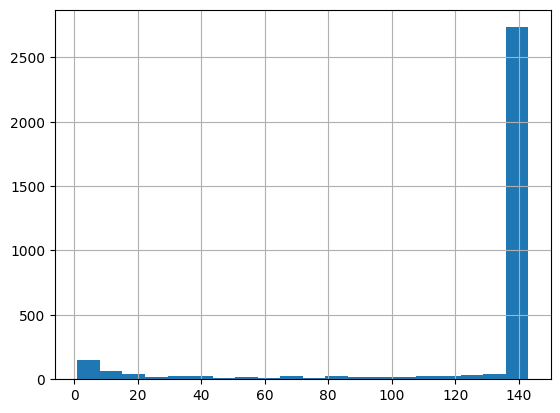

In [10]:
coverage['weeks'].hist(bins=20)
#Mục đích: Đánh giá mức độ đầy đủ của dữ liệu (Data Coverage) cho từng chuỗi thời gian (cặp Store - Dept).
#Nhận xét:Phần lớn các cặp Store-Dept đều có đầy đủ lịch sử bán hàng (143 tuần).

<Axes: xlabel='Dept', ylabel='Store'>

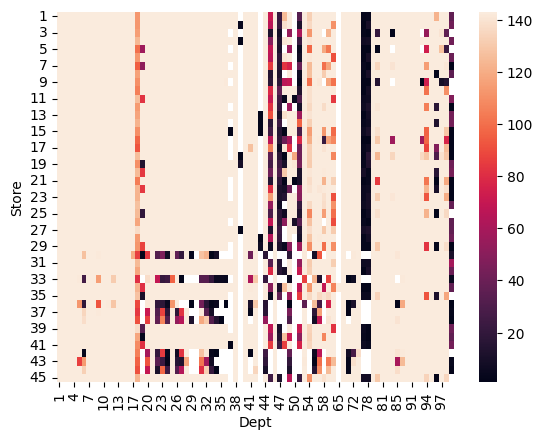

In [11]:
pivot = df_train.pivot_table(
    index='Store', columns='Dept', values='Weekly_Sales', aggfunc='count'
)
import seaborn as sns
sns.heatmap(pivot)

### ♒ Kiểm tra target

<Axes: >

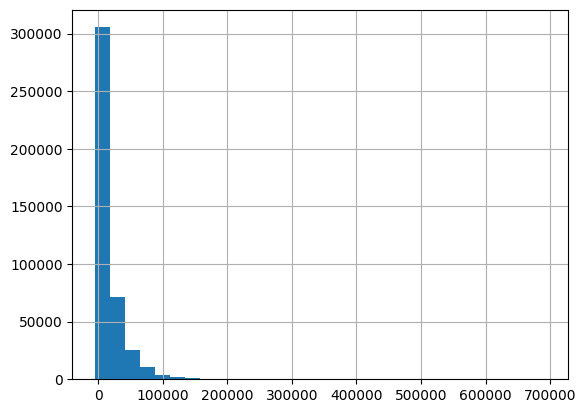

In [12]:
df_train['Weekly_Sales'].hist(bins=30)

<Axes: xlabel='Date'>

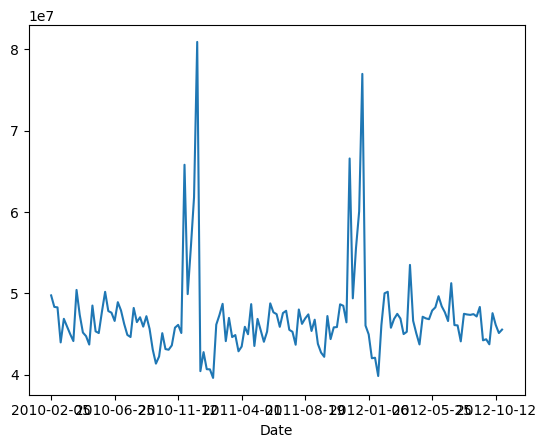

In [13]:
df_train.groupby('Date')['Weekly_Sales'].sum().plot()

<Axes: xlabel='Store'>

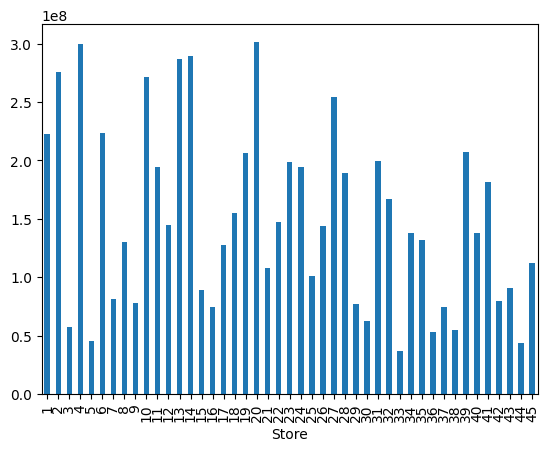

In [14]:
df_train.groupby('Store')['Weekly_Sales'].sum().plot(kind = 'bar')

<Axes: >

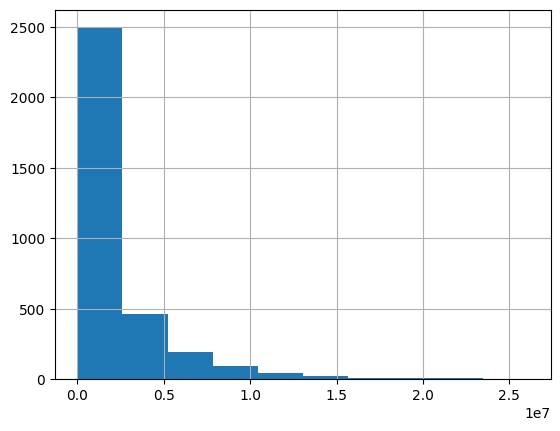

In [15]:
df_train.groupby(['Dept', 'Store'])['Weekly_Sales'].sum().hist()
#Trục hoành X là tổng số doanh thu chia theo 1e7, Trục tung Y là các coverage

### ♒ Merge data

In [16]:
#Chỉ gộp lại khi các parameter trong "on" giống nhau
df_train_1 = pd.merge(df_train, df_features, on=["Store", "Date"], how='inner')

df_test_1 = pd.merge(df_test, df_features, on=["Store", "Date"], how='inner')

df_train_full = pd.merge(df_train_1, df_stores, on=["Store"], how='inner')
#Diện tích của 1 cửa hàng là cố định, nên chỉ cần lấy key
df_test_full = pd.merge(df_test_1, df_stores, on=["Store"], how='inner')

df_train_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday_x   421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  IsHoliday_y   421570 non-null  bool   
 15  Type          421570 non-null  object 
 16  Size          421570 non-null  int64  
dtypes: bool(2), float64(10), int64(3), object(2)
mem

### ♒ Overview bộ dữ liệu

In [17]:
df_train_full.info()
df_test_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday_x   421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  IsHoliday_y   421570 non-null  bool   
 15  Type          421570 non-null  object 
 16  Size          421570 non-null  int64  
dtypes: bool(2), float64(10), int64(3), object(2)
mem

In [18]:
df_train_full

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,False,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,False,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,False,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,False,B,118221


In [19]:
df_test_full

,Store,Dept,Date,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,False,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,False,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,False,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,True,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,False,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115059,45,98,2013-06-28,False,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False,B,118221
115060,45,98,2013-07-05,False,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False,B,118221
115061,45,98,2013-07-12,False,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False,B,118221
115062,45,98,2013-07-19,False,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False,B,118221


In [20]:
df_train_full.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


In [21]:
df_test_full.describe()

,Store,Dept,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,115064.000000,115064.000000,115064.000000,115064.000000,114915.000000,86437.000000,105235.000000,102176.000000,115064.000000,76902.000000,76902.000000,115064.000000
mean,22.238207,44.339524,53.941804,3.581546,7689.216439,3734.051729,2403.088666,3356.219071,3922.681189,176.961347,6.868733,136497.688921
std,12.809930,30.656410,18.724153,0.239442,10698.760716,8323.495014,13767.939313,7570.501545,19445.150745,41.239967,1.583427,61106.926438
min,1.000000,1.000000,-7.290000,2.872000,-2781.450000,-35.740000,-179.260000,0.220000,-185.170000,131.236226,3.684000,34875.000000
25%,11.000000,18.000000,39.820000,3.431000,1966.460000,180.350000,15.100000,155.460000,1309.300000,138.402033,5.771000,93638.000000
50%,22.000000,37.000000,54.470000,3.606000,4842.290000,742.590000,78.260000,840.940000,2390.430000,192.304445,6.806000,140167.000000
75%,33.000000,74.000000,67.350000,3.766000,9439.140000,2735.670000,272.580000,3096.920000,4227.270000,223.244532,8.036000,202505.000000
max,45.000000,99.000000,101.950000,4.125000,103184.980000,71074.170000,149483.310000,65344.640000,771448.100000,228.976456,10.199000,219622.000000


In [22]:
week_data_train = df_train_full.groupby(['Store', 'Dept'])['Weekly_Sales'].count().reset_index(name='Week')
week_data_train

,Store,Dept,Week
0,1,1,143
1,1,2,143
2,1,3,143
3,1,4,143
4,1,5,143
...,...,...,...
3326,45,94,134
3327,45,95,143
3328,45,96,2
3329,45,97,143


In [23]:
week_data_train[week_data_train['Week'] == 143]

,Store,Dept,Week
0,1,1,143
1,1,2,143
2,1,3,143
3,1,4,143
4,1,5,143
...,...,...,...
3323,45,91,143
3324,45,92,143
3325,45,93,143
3327,45,95,143


In [24]:
week_data_train[week_data_train['Week'] < 143]

,Store,Dept,Week
16,1,18,113
41,1,45,71
43,1,47,22
44,1,48,125
46,1,51,33
...,...,...,...
3314,45,78,8
3316,45,80,130
3326,45,94,134
3328,45,96,2


<Axes: >

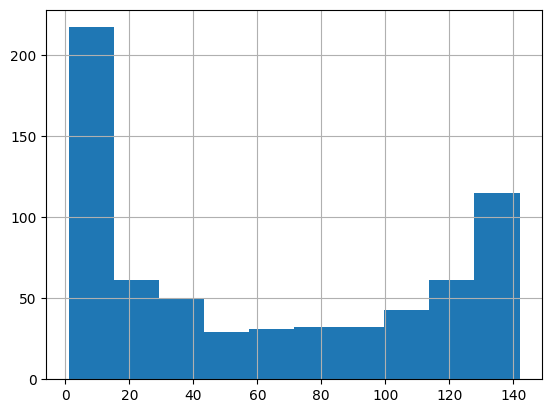

In [25]:
week_data_train[week_data_train['Week'] < 143]['Week'].hist()

## ⚓ Tiền xử lý

### ♒ Xử lí datetime

In [26]:
df_train_full['Date'] = pd.to_datetime(df_train_full['Date'])
df_train_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  IsHoliday_y   421570 non-null  bool          
 15  Type          421

In [27]:
df_test_full['Date'] = pd.to_datetime(df_test_full['Date'])
df_test_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         115064 non-null  int64         
 1   Dept          115064 non-null  int64         
 2   Date          115064 non-null  datetime64[ns]
 3   IsHoliday_x   115064 non-null  bool          
 4   Temperature   115064 non-null  float64       
 5   Fuel_Price    115064 non-null  float64       
 6   MarkDown1     114915 non-null  float64       
 7   MarkDown2     86437 non-null   float64       
 8   MarkDown3     105235 non-null  float64       
 9   MarkDown4     102176 non-null  float64       
 10  MarkDown5     115064 non-null  float64       
 11  CPI           76902 non-null   float64       
 12  Unemployment  76902 non-null   float64       
 13  IsHoliday_y   115064 non-null  bool          
 14  Type          115064 non-null  object        
 15  Size          115

### ♒ Xử lý duplicated

In [28]:
if df_train_full['IsHoliday_x'].equals(df_train_full['IsHoliday_y']):
  df_train_full = df_train_full.drop(columns=['IsHoliday_y'])
if df_test_full['IsHoliday_x'].equals(df_test_full['IsHoliday_y']):
  df_test_full = df_test_full.drop(columns=['IsHoliday_y'])
df_train_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

### ♒ Xử lý Category

In [29]:
df_train_full['IsHoliday_x'] = df_train_full['IsHoliday_x'].astype(int)
df_test_full['IsHoliday_x'] = df_test_full['IsHoliday_x'].astype(int)

df_train_full.info()
df_test_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  int64         
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [30]:
import pandas as pd
df_train_full = pd.get_dummies(df_train_full, columns=['Type'])
df_test_full = pd.get_dummies(df_test_full, columns=['Type'])

df_train_full.info()
df_test_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  int64         
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Size          421570 non-null  int64         
 15  Type_A        421

## ⚓ Xử lý missing value

In [31]:
mark_down_col = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df_train_full[mark_down_col] = df_train_full[mark_down_col].fillna(0)
df_train_full.info()

df_test_full[mark_down_col] = df_test_full[mark_down_col].fillna(0)
df_test_full.info()

features_col = ['CPI', 'Unemployment']
df_test_full[features_col] = df_test_full[features_col].ffill()

df_test_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday_x   421570 non-null  int64         
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Size          421570 non-null  int64         
 15  Type_A        421

In [32]:
df_train_full[mark_down_col] = df_train_full[mark_down_col].clip(lower=0)
df_train_full.describe()



,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.258123,0.070358,60.090059,3.361027,2590.074819,880.070274,468.092929,1083.132268,1662.772385,171.201947,7.960289,136727.915739
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,0.000000,-2.060000,2.472000,0.000000,0.000000,0.000000,0.000000,0.000000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,0.000000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,0.000000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,0.000000,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,1.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.785297,30.492054,NaN,22711.183519,0.255750,18.447931,0.458515,6052.385934,5084.520381,5528.872994,3894.529945,4207.629321,39.159276,1.863296,60980.583328


In [33]:
df_test_full[mark_down_col] = df_test_full[mark_down_col].clip(lower=0)
df_test_full.describe()

,Store,Dept,Date,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,115064.000000,115064.000000,115064,115064.000000,115064.000000,115064.000000,115064.000000,115064.000000,115064.000000,115064.000000,115064.000000,115064.000000,115064.000000,115064.000000
mean,22.238207,44.339524,2013-03-14 14:39:41.311270144,0.077592,53.941804,3.581546,7681.106189,2805.085103,2198.021241,2980.298267,3922.806060,177.170401,6.815989,136497.688921
min,1.000000,1.000000,2012-11-02 00:00:00,0.000000,-7.290000,2.872000,0.000000,0.000000,0.000000,0.000000,0.000000,131.236226,3.684000,34875.000000
25%,11.000000,18.000000,2013-01-04 00:00:00,0.000000,39.820000,3.431000,1963.550000,0.000000,7.770000,70.370000,1309.300000,138.424667,5.639000,93638.000000
50%,22.000000,37.000000,2013-03-15 00:00:00,0.000000,54.470000,3.606000,4828.720000,316.880000,60.000000,600.580000,2390.430000,192.358548,6.791000,140167.000000
75%,33.000000,74.000000,2013-05-24 00:00:00,0.000000,67.350000,3.766000,9427.410000,1575.850000,244.200000,2627.850000,4227.270000,223.610984,7.992000,202505.000000
max,45.000000,99.000000,2013-07-26 00:00:00,1.000000,101.950000,4.125000,103184.980000,71074.170000,149483.310000,65344.640000,771448.100000,228.976456,10.199000,219622.000000
std,12.809930,30.656410,NaN,0.267529,18.724153,0.239442,10693.903634,7392.542823,13183.852299,7212.030921,19445.125049,41.290365,1.579504,61106.926438


In [34]:
df_train_full['Weekly_Sales'] = df_train_full['Weekly_Sales'].clip(lower=0)
df_train_full.describe()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375104,15981.467250,0.070358,60.090059,3.361027,2590.074819,880.070274,468.092929,1083.132268,1662.772385,171.201947,7.960289,136727.915739
min,1.000000,1.000000,2010-02-05 00:00:00,0.000000,0.000000,-2.060000,2.472000,0.000000,0.000000,0.000000,0.000000,0.000000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,0.000000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,0.000000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,0.000000,74.280000,3.738000,2809.050000,2.200000,4.540000,425.290000,2168.040000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,1.000000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.785297,30.492054,NaN,22711.032446,0.255750,18.447931,0.458515,6052.385934,5084.520381,5528.872994,3894.529945,4207.629321,39.159276,1.863296,60980.583328


## ⚓ Feature Engineering

### ♒Tạo các feature mới sau khi Deep EDA

In [35]:
# import pandas as pd

# df_train_full['Date'] = pd.to_datetime(df_train_full['Date'])
# df_train_full['Month'] = df_train_full['Date'].dt.month

# # 1. Đánh dấu tháng 10
# df_train_full['Is_October'] = (df_train_full['Month'] == 10).astype(int)

# # 2. Đánh dấu Store và Dept có sai số lớn
# high_error_stores = [14, 28, 4, 20, 11]
# high_error_depts = [38, 72, 92, 95, 90]
# df_train_full['Is_High_Error_Store'] = df_train_full['Store'].isin(high_error_stores).astype(int)
# df_train_full['Is_High_Error_Dept'] = df_train_full['Dept'].isin(high_error_depts).astype(int)

# # 3. Interaction feature
# df_train_full['Oct_Risk_Dept'] = df_train_full['Is_October'] * df_train_full['Is_High_Error_Dept']

# # 4. Avg_Sales_Oct_Dept — tính từ train để tránh data leakage
# october_train_data = df_train_full[df_train_full['Month'] == 10]
# dept_oct_avg = october_train_data.groupby('Dept')['Weekly_Sales'].mean().reset_index()
# dept_oct_avg.rename(columns={'Weekly_Sales': 'Avg_Sales_Oct_Dept'}, inplace=True)

# df_train_full = df_train_full.merge(dept_oct_avg, on='Dept', how='left')
# df_train_full['Avg_Sales_Oct_Dept'] = df_train_full['Avg_Sales_Oct_Dept'].fillna(0)

# # 5. Áp dụng tương tự cho df_test_full
# df_test_full['Date'] = pd.to_datetime(df_test_full['Date'])
# df_test_full['Month'] = df_test_full['Date'].dt.month
# df_test_full['Is_October'] = (df_test_full['Month'] == 10).astype(int)
# df_test_full['Is_High_Error_Store'] = df_test_full['Store'].isin(high_error_stores).astype(int)
# df_test_full['Is_High_Error_Dept'] = df_test_full['Dept'].isin(high_error_depts).astype(int)
# df_test_full['Oct_Risk_Dept'] = df_test_full['Is_October'] * df_test_full['Is_High_Error_Dept']
# df_test_full = df_test_full.merge(dept_oct_avg, on='Dept', how='left')
# df_test_full['Avg_Sales_Oct_Dept'] = df_test_full['Avg_Sales_Oct_Dept'].fillna(0)

# print("✅ Feature Engineering hoàn tất. Sẵn sàng tạo lag/rolling.")

### ♒Lag Feature và Split data

In [36]:
def create_safe_lag_feature(data, group_cols, target_col, lags):
    """
    Tạo cột lag an toàn cho Time Series có nhiều nhóm (Store, Dept)

    - group_cols: list các cột để gom nhóm (VD: ['Store', 'Department'])
    - target_col: Cột cần tính lag (VD: 'Weekly_Sales')
    - lags: list các độ trễ muốn tạo (VD: [1, 2, 4])
    """
    df = data.copy() # Tạo bản sao để không làm hỏng data gốc

    # Bắt buộc phải sắp xếp thời gian tăng dần trước khi shift
    df = df.sort_values(by=group_cols + ['Date'])

    for k in lags:
        # Groupby theo Store & Dept, sau đó mới shift
        df[f'{target_col}_lag_{k}'] = df.groupby(group_cols)[target_col].shift(k)

    return df

In [37]:
import pandas as pd

def split_data(train_data, config):
    """
    train_data: df_train_full (Dữ liệu huấn luyện đã merge)
    config : nơi chứa các tham số
    Cấu trúc:
    config['split_data'] = {
            'start_date' : '2010-02-05',
            'train_size' : 110,
            'val_1' : 10,
            'val_2' : 10,
            'val_3' : 10,
            'test_size' :3
        },

    """

    cfg = config['split_data']
    train_data = train_data.sort_values('Date')
    start_date = pd.to_datetime(cfg['start_date'])
    train_end = start_date + pd.Timedelta(weeks=cfg['train_size'])

    val1_end = train_end + pd.Timedelta(weeks=cfg['val_1'])
    val2_end = val1_end + pd.Timedelta(weeks=cfg['val_2'])
    val3_end = val2_end + pd.Timedelta(weeks=cfg['val_3'])
    test_end = val3_end + pd.Timedelta(weeks=cfg['test_size'])

    train_set = train_data[train_data['Date'] < train_end].copy() #Từ tuần 1 tới tuần 110

    val1 = train_data[(train_data['Date'] >= train_end) & (train_data['Date'] < val1_end)].copy() #Test thử Từ tuần 110 đến tuần 120
    val2 = train_data[(train_data['Date'] >= val1_end) & (train_data['Date'] < val2_end)].copy() #Từ tuần 120 đến tuần 130
    val3 = train_data[(train_data['Date'] >= val2_end) & (train_data['Date'] < val3_end)].copy() #Từ tuần 130 đến tuần 140

    # validation_set = (val1, val2, val3)

    test_set = train_data[(train_data['Date'] >= val3_end) & (train_data['Date'] <= test_end)].copy() #Test thật Từ tuần 150 đến tuần 153

    return train_set, val1, val2, val3, test_set

# train_set, validation_set, test_set= split_data(df_train_full, config)

In [38]:
def create_lag_rolling_feature_single(df, config):
    """
    Tạo lag và rolling feature trên TOÀN BỘ dữ liệu nguyên khối.
    df: Dataframe gốc (vd: df_train_full)
    config: Chứa tham số groupby và lag_rolling
    """
    group_cfg = config['groupby']
    lag_rolling_cfg = config['lag_rolling']

    # Tạo bản sao để không ảnh hưởng dữ liệu gốc
    data = df.copy()

    # 1. Bắt buộc Sort để đảm bảo đúng thứ tự thời gian
    data = data.sort_values(['Store', 'Dept', 'Date'])

    # 2. Gom nhóm theo Store và Dept
    grouped = data.groupby(['Store', 'Dept'])['Weekly_Sales']

    # 3. Tạo Lag features
    for lag in lag_rolling_cfg['lags']:
        data[f'lag_{lag}'] = grouped.shift(lag)

    # 4. Tạo Rolling features (nhớ có shift(1) để chống rò rỉ dữ liệu)
    for window in lag_rolling_cfg['windows']:
        data[f'rolling_mean_{window}'] = grouped.shift(1).rolling(window).mean()
        data[f'rolling_std_{window}'] = grouped.shift(1).rolling(window).std()
    # Tạo danh sách các cột vừa sinh ra
    new_cols = [f'lag_{lag}' for lag in lag_rolling_cfg['lags']] + \
           [f'rolling_mean_{w}' for w in lag_rolling_cfg['windows']] + \
           [f'rolling_std_{w}' for w in lag_rolling_cfg['windows']]
    data = data.dropna(subset=new_cols)

    return data

In [39]:
df_full_with_features = create_lag_rolling_feature_single(df_train_full, config)
train_set, val1, val2, val3, test_set = split_data(df_full_with_features, config)
datasets = [train_set, val1, val2, val3, test_set]
test_set

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Type_B,Type_C,lag_1,lag_2,lag_3,lag_52,rolling_mean_2,rolling_std_2,rolling_mean_3,rolling_std_3
410498,44,85,2012-10-12,97.26,0,55.10,3.797,69.96,0.00,3.05,...,False,True,199.40,92.20,129.70,63.48,145.800,75.801847,140.433333,54.400031
315186,33,9,2012-10-12,22.72,0,79.64,4.468,33.23,0.00,0.00,...,False,False,24.44,13.20,22.72,41.78,18.820,7.947880,20.120000,6.054292
134621,14,54,2012-10-12,0.00,0,54.47,4.000,3214.56,0.00,20.28,...,False,False,28.92,38.80,40.92,96.76,33.860,6.986215,36.213333,6.404540
136059,14,79,2012-10-12,32134.27,0,54.47,4.000,3214.56,0.00,20.28,...,False,False,32396.71,27985.78,31048.90,33989.14,30191.245,3118.998514,30477.130000,2260.368679
324597,34,30,2012-10-12,1302.92,0,59.94,3.603,2254.65,0.00,29.82,...,False,False,1589.74,1321.42,2007.42,1435.48,1455.580,189.730892,1639.526667,345.699341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335758,35,38,2012-10-26,40767.08,0,58.99,3.882,6221.06,42.48,103.00,...,True,False,31436.48,35829.64,38887.00,32487.91,33633.060,3106.433227,35384.373333,3745.164732
111875,12,29,2012-10-26,7703.18,0,65.95,4.301,13749.10,104.54,56.00,...,True,False,6021.58,5623.04,5842.23,7648.37,5822.310,281.810337,5828.950000,199.601607
335615,35,36,2012-10-26,3494.23,0,58.99,3.882,6221.06,42.48,103.00,...,True,False,3872.78,2599.58,2016.55,3746.22,3236.180,900.288354,2829.636667,949.258661
333756,35,23,2012-10-26,36645.68,0,58.99,3.882,6221.06,42.48,103.00,...,True,False,42468.53,41867.99,38197.31,40477.93,42168.260,424.645906,40844.610000,2312.208909


In [40]:
train_label = datasets[0]['Weekly_Sales'].copy()
val1_label = datasets[1]['Weekly_Sales'].copy()
val2_label = datasets[2]['Weekly_Sales'].copy()
val3_label = datasets[3]['Weekly_Sales'].copy()
test_label = datasets[4]['Weekly_Sales'].copy()


## ⚓Baseline model

In [41]:
import numpy as np

def get_weights_single(df):
    return np.where(df['IsHoliday_x'] == 1, 5, 1)
test_clean = test_set.dropna(subset=['lag_52', 'Weekly_Sales']).copy()
y_true = test_clean['Weekly_Sales']
y_pred = test_clean['lag_52']
weights = get_weights_single(test_clean)
wmae = np.sum(weights * abs(y_true - y_pred)) / np.sum(weights)

print(f"Điểm Seasonal Naive Baseline (WMAE): {wmae:.2f}")

Điểm Seasonal Naive Baseline (WMAE): 1785.66


## ⚓ First ML model

In [42]:
import xgboost as xgb
import numpy as np

# 1. Tách X, y và loại bỏ cột không cần thiết
cols_to_drop = ['Weekly_Sales', 'Date']

X_train = train_set.drop(columns=cols_to_drop)
y_train = train_set['Weekly_Sales']

X_val = val1.drop(columns=cols_to_drop)
y_val = val1['Weekly_Sales']

X_test = test_set.drop(columns=cols_to_drop)

# 2. Tính trọng số
weights_train = get_weights_single(train_set)
weights_val = get_weights_single(val1)

# 3. Khởi tạo mô hình
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    early_stopping_rounds=50
)

# 4. Huấn luyện mô hình
print("Đang huấn luyện XGBoost...")
xgb_model.fit(
    X_train, y_train,
    sample_weight=weights_train,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[weights_val],
    verbose=False # Tắt log dài dòng để màn hình gọn gàng hơn
)

# 5. Dự báo và tính điểm
y_pred_xgb = xgb_model.predict(X_test)

weights_test = get_weights_single(test_set)
wmae_xgb = np.sum(weights_test * abs(y_true - y_pred_xgb)) / np.sum(weights_test)

print("-" * 30)
print(f"Điểm Baseline (Cũ): 1785.66")
print(f"Điểm XGBoost khi áp dụng feature engineering: 1471.94")
print(f"Điểm XGBoost sau khi đã cắt bỏ phần feature engineering đó (Mới): {wmae_xgb:.2f}")

Đang huấn luyện XGBoost...
------------------------------
Điểm Baseline (Cũ): 1785.66
Điểm XGBoost khi áp dụng feature engineering: 1471.94
Điểm XGBoost sau khi đã cắt bỏ phần feature engineering đó (Mới): 1337.50


## ⚓ Deep EDA

### ♒Feature Important

In [43]:
import pandas as pd

# Lấy importance
importance = xgb_model.feature_importances_

# Gắn với tên cột
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
})

# Sắp xếp giảm dần
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print(feature_importance_df.head(15))

           feature  importance
19          lag_52    0.572117
22  rolling_mean_3    0.204145
16           lag_1    0.074794
20  rolling_mean_2    0.034354
7        MarkDown3    0.028570
6        MarkDown2    0.009720
17           lag_2    0.007971
21   rolling_std_2    0.007133
2      IsHoliday_x    0.006787
11    Unemployment    0.006713
12            Size    0.006477
1             Dept    0.006220
13          Type_A    0.005796
5        MarkDown1    0.004340
18           lag_3    0.004190


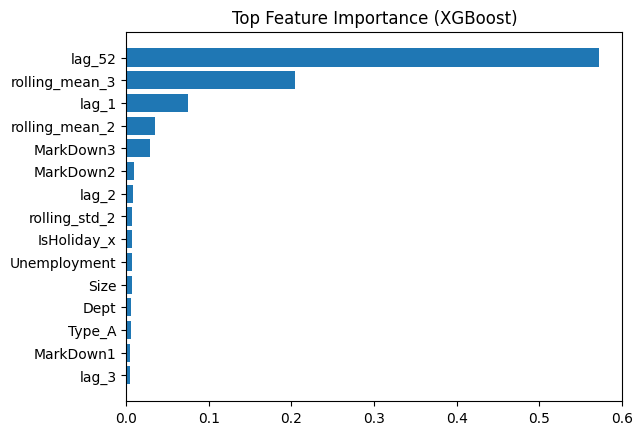

In [44]:
import matplotlib.pyplot as plt

top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure()
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importance (XGBoost)")
plt.show()

### ♒ Error Analysis

In [45]:
import pandas as pd

# 1. Tạo DataFrame chứa thông tin của tập test kèm theo dự báo và thực tế
error_df = test_set.copy()
error_df['Actual_Sales'] = y_true.values
error_df['Pred_Sales'] = y_pred_xgb

# 2. Tính sai số tuyệt đối (Absolute Error)
error_df['Abs_Error'] = abs(error_df['Actual_Sales'] - error_df['Pred_Sales'])

# 3. Lấy Top 100 dòng mô hình đoán sai nhiều nhất
top_100_errors = error_df.sort_values(by='Abs_Error', ascending=False).head(100)

display(top_100_errors[['Date', 'Store', 'Dept', 'Actual_Sales', 'Pred_Sales', 'Abs_Error']].head(10))

,Date,Store,Dept,Actual_Sales,Pred_Sales,Abs_Error
95472,2012-10-19,10,72,101213.23,153608.203125,52394.973125
149306,2012-10-19,16,9,111246.19,59921.695312,51324.494688
195187,2012-10-19,20,72,63571.41,107333.390625,43761.980625
135764,2012-10-19,14,72,69389.31,106180.382812,36791.072813
17995,2012-10-19,2,72,52176.54,84362.671875,32186.131875
137346,2012-10-12,14,92,156174.21,186495.296875,30321.086875
135765,2012-10-26,14,72,63071.17,93198.296875,30127.126875
37300,2012-10-19,4,72,91918.26,118428.921875,26510.661875
17996,2012-10-26,2,72,48941.21,75311.640625,26370.430625
224510,2012-10-19,23,72,58041.44,83979.992188,25938.552187


In [46]:
print("--- Tần suất sai số lớn theo Loại cửa hàng ---")
print(top_100_errors[['Type_A', 'Type_B', 'Type_C']].sum())

--- Tần suất sai số lớn theo Loại cửa hàng ---
Type_A    68
Type_B    28
Type_C     4
dtype: int64


In [47]:
print("\n--- Số lượng sai số lớn rơi vào tuần Lễ ---")
print(top_100_errors['IsHoliday_x'].value_counts())


--- Số lượng sai số lớn rơi vào tuần Lễ ---
IsHoliday_x
0    100
Name: count, dtype: int64


In [48]:
print("\n--- Top Store bị sai số nhiều nhất ---")
print(top_100_errors['Store'].value_counts().head(5))

print("\n--- Top Dept bị sai số nhiều nhất ---")
print(top_100_errors['Dept'].value_counts().head(5))


--- Top Store bị sai số nhiều nhất ---
Store
14    12
28    11
4     10
20     6
11     5
Name: count, dtype: int64

--- Top Dept bị sai số nhiều nhất ---
Dept
38    28
72    23
92    18
95     5
90     4
Name: count, dtype: int64


In [49]:
# Rút trích tháng từ cột Date
top_100_errors['Month'] = pd.to_datetime(top_100_errors['Date']).dt.month
print("\n--- Sai số lớn theo Tháng ---")
print(top_100_errors['Month'].value_counts().sort_index())


--- Sai số lớn theo Tháng ---
Month
10    100
Name: count, dtype: int64


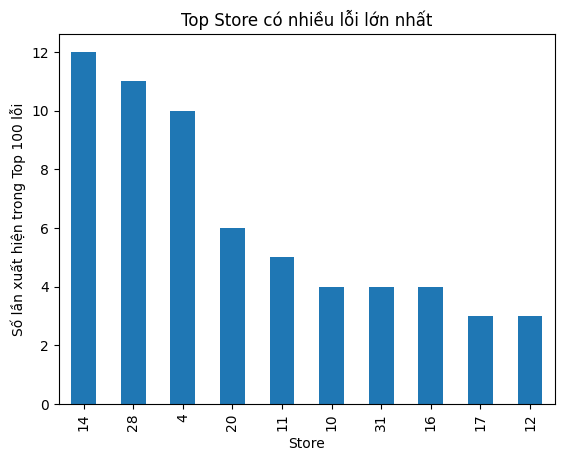

In [50]:
import matplotlib.pyplot as plt

top_100_errors['Store'].value_counts().head(10).plot(kind='bar')
plt.title("Top Store có nhiều lỗi lớn nhất")
plt.xlabel("Store")
plt.ylabel("Số lần xuất hiện trong Top 100 lỗi")
plt.show()

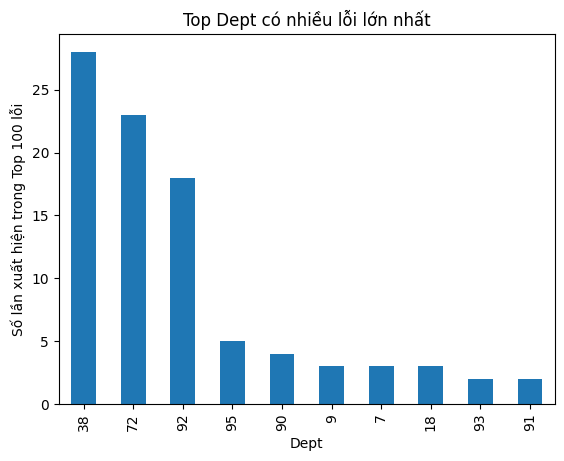

In [51]:
import matplotlib.pyplot as plt

top_100_errors['Dept'].value_counts().head(10).plot(kind='bar')
plt.title("Top Dept có nhiều lỗi lớn nhất")
plt.xlabel("Dept")
plt.ylabel("Số lần xuất hiện trong Top 100 lỗi")
plt.show()

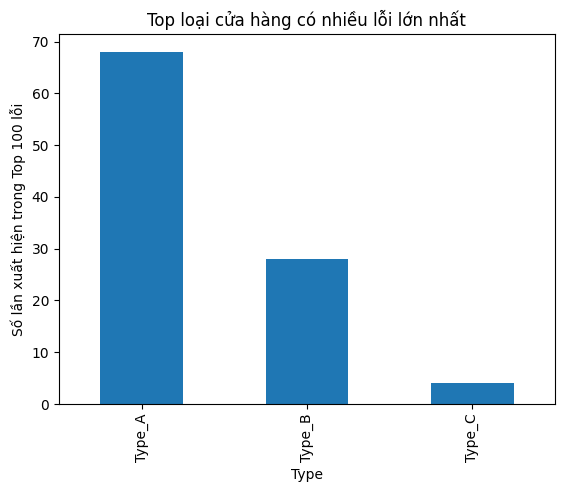

In [52]:
import matplotlib.pyplot as plt

top_100_errors[['Type_A', 'Type_B', 'Type_C']].sum().plot(kind='bar')
plt.title("Top loại cửa hàng có nhiều lỗi lớn nhất")
plt.xlabel("Type")
plt.ylabel("Số lần xuất hiện trong Top 100 lỗi")
plt.show()

In [53]:
# So sánh Store
print("Só store chiếm nhiều bộ dữ liệu nhất:")
print(error_df['Store'].value_counts(normalize=True).head())

print("\nTop lỗi:")
print(top_100_errors['Store'].value_counts(normalize=True).head())

Só store chiếm nhiều bộ dữ liệu nhất:
Store
13    0.024832
10    0.024718
1     0.024490
2     0.024376
6     0.024262
Name: proportion, dtype: float64

Top lỗi:
Store
14    0.12
28    0.11
4     0.10
20    0.06
11    0.05
Name: proportion, dtype: float64


## ⚓ Hyperparameter Tuning

In [54]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

def objective(trial):
    params = {
        'tree_method'     : 'hist',   # Sử dụng thuật toán Histogram (nhanh hơn)
        'device'          : 'cuda',   # Ép XGBoost chạy trên GPU NVIDIA RTX 4050
        'n_estimators'    : trial.suggest_int('n_estimators', 300, 1000),
        'n_estimators'    : trial.suggest_int('n_estimators', 300, 1000),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 4, 8),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'objective'       : 'reg:squarederror',
        'random_state'    : 42,
    }
    model = xgb.XGBRegressor(**params, early_stopping_rounds=30)
    model.fit(
        X_train, y_train,
        sample_weight=weights_train,
        eval_set=[(X_val, y_val)],
        sample_weight_eval_set=[weights_val],
        verbose=False
    )
    y_pred = model.predict(X_val)
    return np.sum(weights_val * np.abs(y_val - y_pred)) / np.sum(weights_val)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("Best WMAE  :", study.best_value)
print("Best params:", study.best_params)

[I 2026-05-13 05:13:18,463] A new study created in memory with name: no-name-484113c0-6014-4495-8278-82bba4c47b83
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [05:13:21] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-05-13 05:13:21,086] Trial 0 finished with value: 1596.0876958384085 and parameters: {'n_estimators': 597, 'learning_rate': 0.011746158110783661, 'max_depth': 5, 'subsample': 0.8679492681110723, 'colsample_bytree': 0.9101114121284456, 'min_child_weight': 7}. Best is trial 0 with value: 1596.0876958384085.
[I 2026-05-13 05:

Best WMAE  : 1550.9756332275776
Best params: {'n_estimators': 473, 'learning_rate': 0.02593800284066961, 'max_depth': 8, 'subsample': 0.8151940023874932, 'colsample_bytree': 0.9479479446957284, 'min_child_weight': 10}


# ⚓ Final Model

In [56]:
# Combine train + all validation sets for final training
df_train_final = pd.concat([train_set, val1, val2, val3], axis=0).sort_values('Date')

X_train_final = df_train_final.drop(columns=['Weekly_Sales', 'Date'])
y_train_final = df_train_final['Weekly_Sales']
weights_final = get_weights_single(df_train_final)

best_params = study.best_params
best_params['objective'] = 'reg:squarederror'
best_params['random_state'] = 42

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_train_final, y_train_final, sample_weight=weights_final)

y_pred_final = final_model.predict(X_test)
wmae_final = np.sum(weights_test * np.abs(y_true - y_pred_final)) / np.sum(weights_test)
print(f"Tuned XGBoost (full train) WMAE: {wmae_final:.2f}")

Tuned XGBoost (full train) WMAE: 1200.60


In [57]:
scores = []
for val_set in [val1, val2, val3]:
    X_v = val_set.drop(columns=['Weekly_Sales', 'Date'])
    y_v = val_set['Weekly_Sales']
    w_v = get_weights_single(val_set)
    pred = final_model.predict(X_v)
    wmae = np.sum(w_v * np.abs(y_v - pred)) / np.sum(w_v)
    scores.append(wmae)

print(f"Val1 WMAE: {scores[0]:.2f}")
print(f"Val2 WMAE: {scores[1]:.2f}")
print(f"Val3 WMAE: {scores[2]:.2f}")
print(f"Average  : {np.mean(scores):.2f}")

Val1 WMAE: 1241.43
Val2 WMAE: 1104.43
Val3 WMAE: 1009.11
Average  : 1118.32


In [58]:
import joblib
joblib.dump(final_model, 'xgb_sales_model.pkl')
print("Đã lưu mô hình thành công!")

Đã lưu mô hình thành công!


In [60]:
df_combined = pd.concat([df_train_full, df_test_full], axis=0).sort_values(['Store', 'Dept', 'Date'])
df_combined_with_features = create_lag_rolling_feature_single(df_combined, config)

test_submission = df_combined_with_features[df_combined_with_features['Date'].isin(df_test_full['Date'])]
X_submission = test_submission.drop(columns=['Weekly_Sales', 'Date'], errors='ignore')

submission_preds = final_model.predict(X_submission)
submission_df = test_submission[['Store', 'Dept', 'Date']].copy()
submission_df['Weekly_Sales'] = submission_preds
submission_df.to_csv('submission.csv', index=False)